In [1]:
# Test case
import numpy as np
from dgp import DGP
from LassoEstimatorTheory import LassoEstimatorTheory

dgp = DGP(signal_type="strong")
data = dgp.generate()

X, y, beta, support = data["X"], data["y"], data["beta"], data["support"]
estimator = LassoEstimatorTheory()
beta_hat = estimator.fit(X, y, lam=0.1, thresholding_level=0.05, apply_threshold=True, support_true=support)

{
    "beta_hat_nonzero_count": np.count_nonzero(beta_hat),
    "support_size": estimator.support_size,
    "perfect_match": estimator.perfect_match,
    "mse_train": np.mean(estimator.residuals ** 2)
}

{'beta_hat_nonzero_count': 44,
 'support_size': 44,
 'perfect_match': False,
 'mse_train': np.float64(1.5335704851436753)}

In [2]:
import numpy as np
from config import Config
from dgp import DGP
from LassoEstimatorTheory import LassoEstimatorTheory
from bootstraps.modified import ModifiedBootstrap

# Set random seed for reproducibility
Config.set_random_seed(42)

# Generate data
dgp = DGP(signal_type="strong", error_type="heteroskedastic", seed=Config.seed)
data = dgp.generate()

X, y, beta_true, support, snr = data["X"], data["y"], data["beta"], data["support"], data["snr"]

# Select lambda and threshold value manually (theory-based fixed values)
lambda_val = 0.1
threshold_val = Config.get_threshold(alpha_th=0.25)

# Fit Lasso using theory-driven estimator
estimator = LassoEstimatorTheory()
beta_hat = estimator.fit(
    X=X,
    y=y,
    lam=lambda_val,
    thresholding_level=threshold_val,
    apply_threshold=True,
    support_true=support
)

# Run modified bootstrap
bootstrap = ModifiedBootstrap(X, y, estimator.beta_hat, beta_true, threshold_val)
boot_results = bootstrap.generate_bootstrap_distribution(B=Config.num_bootstrap, lam=lambda_val, level=0.90)

# Collect test outputs for inspection
test_outputs = {
    "beta_hat": estimator.beta_hat,
    "beta_tilde": estimator.beta_tilde,
    "residuals": estimator.residuals,
    "active_set": estimator.active_set,
    "support_size": estimator.support_size,
    "perfect_match": estimator.perfect_match,
    "bootstrap_mean": boot_results["mean"],
    "bootstrap_std": boot_results["std"],
    "ci_lower": boot_results["ci_lower"],
    "ci_upper": boot_results["ci_upper"],
    "ci_length": boot_results["ci_length"],
    "coverage": boot_results["coverage"]
}


# Print test outputs
for key, value in test_outputs.items():
    print(f"{key}: {value}")

test_outputs.keys()

beta_hat: [-0.00000000e+00 -2.62703744e-02  0.00000000e+00 -3.92391436e-01
  6.05674863e-01  5.18632089e+00 -2.74591982e-02 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -6.79650711e-01 -4.79043587e-02
  4.13039902e-01 -0.00000000e+00 -2.90472018e-01 -6.34998491e-01
  3.67932225e-02 -3.24352136e-01  3.00014697e-01 -0.00000000e+00
 -4.43706946e+00  8.63420564e-02 -8.54970433e-01 -0.00000000e+00
  0.00000000e+00  1.22232149e-01 -0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -3.07663798e-01  0.00000000e+00 -3.63129917e-01 -0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  8.40929391e-02
 -8.19335653e-02  0.00000000e+00  0.00000000e+00  1.70678486e-01
  0.00000000e+00  9.52080618e+00  5.14042960e-02 -0.00000000e+00
  2.59250631e-02 -0.00000000e+00 -2.15160286e-01 -0.00000000e+00
  0.00000000e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -3.48268067e-01 -4.40854255e-01  5.50194932e-01 -0.00000000e+00
  0.00000000e+0

dict_keys(['beta_hat', 'beta_tilde', 'residuals', 'active_set', 'support_size', 'perfect_match', 'bootstrap_mean', 'bootstrap_std', 'ci_lower', 'ci_upper', 'ci_length', 'coverage'])

In [ ]:
from simulation import SimulationRunner

# Set up and run the simulation with the modified bootstrap
runner = SimulationRunner(
    method="modified",
    lambda_val=0.1,
    threshold_val=0.25,               # corresponds to a = α_th * sqrt(log(p)/n)
    signal_type="strong",               # choose from 'strong', 'weak', 'nearzero'
    error_type="heteroskedastic",       # choose from 'gaussian', 'heteroskedastic', 'ar1'
    level=0.90,
    tracked_indices=[5, 20],            # beta_j to track
    subdir="results/test_modified_bootstrap"
)

results = runner.run()

# Extract summary for inspection
summary_df = results["summary_df"]
print(summary_df.head())

In [ ]:
summary_df.to_csv("results/summary.csv", index=False)

In [ ]:
from dgp import DGP
from config import Config
import pandas as pd
import numpy as np

# Define combinations of signal strength and error type
test_cases = [
    ("strong", "gaussian"),
    ("weak", "heteroskedastic"),
    ("nearzero", "ar1"),
    ("strong", "heteroskedastic"),
    ("weak", "gaussian"),
]

# Storage for summary output
summaries = []

for i, (signal_type, error_type) in enumerate(test_cases, start=1):
    print(f"Test Case {i}: Signal = {signal_type}, Error = {error_type}")
    
    dgp = DGP(signal_type=signal_type, error_type=error_type, seed=42 + i)
    data = dgp.generate()

    # Display diagnostics
    print("  X shape:", data["X"].shape)
    print("  y shape:", data["y"].shape)
    print("  β support indices:", data["support"])
    print("  First 5 nonzero β:", data["beta"][data["support"][:5]])
    print("  First 5 errors:", data["errors"][:5])
    print("  SNR:", round(data["snr"], 3))
    print("-" * 60)

    # Save for summary table
    summaries.append({
        "Case": f"{signal_type} / {error_type}",
        "SNR": round(data["snr"], 3),
        "Support": data["support"],
        "First beta": np.round(data["beta"][data["support"][:3]], 2).tolist()
    })

# Display all summaries as a table
df_summary = pd.DataFrame(summaries)
display(df_summary)


Test Case 1: Signal = strong, Error = gaussian
  X shape: (200, 300)
  y shape: (200,)
  β support indices: [5, 20, 45, 70, 100, 130, 160, 200, 240, 280]
  First 5 nonzero β: [ 5. -4. 10. -6.  2.]
  First 5 errors: [ 0.82531095 -0.31365323  0.66569764  0.49029959  1.08686477]
  SNR: 290.934
------------------------------------------------------------
Test Case 2: Signal = weak, Error = heteroskedastic
  X shape: (200, 300)
  y shape: (200,)
  β support indices: [5, 20, 45, 70, 100, 130, 160, 200, 240, 280]
  First 5 nonzero β: [ 4.   -0.25  0.75  0.35  1.  ]
  First 5 errors: [-1.89396187 -4.32287984 -1.04370817 -7.4947376   4.72697035]
  SNR: 0.847
------------------------------------------------------------
Test Case 3: Signal = nearzero, Error = ar1
  X shape: (200, 300)
  y shape: (200,)
  β support indices: [5, 20, 45, 70, 100, 130, 160, 200, 240, 280]
  First 5 nonzero β: [ 0.07071068 -0.21213203  1.          0.35        0.8       ]
  First 5 errors: [-0.06047396 -2.94795272 -0.2

,Case,SNR,Support,First beta
0,strong / gaussian,290.934,"[5, 20, 45, 70, 100, 130, 160, 200, 240, 280]","[5.0, -4.0, 10.0]"
1,weak / heteroskedastic,0.847,"[5, 20, 45, 70, 100, 130, 160, 200, 240, 280]","[4.0, -0.25, 0.75]"
2,nearzero / ar1,6.389,"[5, 20, 45, 70, 100, 130, 160, 200, 240, 280]","[0.07, -0.21, 1.0]"
3,strong / heteroskedastic,9.817,"[5, 20, 45, 70, 100, 130, 160, 200, 240, 280]","[5.0, -4.0, 10.0]"
4,weak / gaussian,25.762,"[5, 20, 45, 70, 100, 130, 160, 200, 240, 280]","[4.0, -0.25, 0.75]"


In [ ]:
from dgp import DGP
from config import Config
from LassoEstimatorTheory import LassoEstimatorTheory
import pandas as pd
import numpy as np

# Thresholding constant
a_n = 0.25 * np.sqrt(np.log(Config.p) / Config.n)

# Lambda grid and bootstrap settings
lambda_grid = np.linspace(0.01, 1.0, 20)
B = 100  # Bootstrap replicates for lambda selection

# DGP combinations
test_cases = [
    ("strong", "gaussian"),
    ("weak", "heteroskedastic"),
    ("nearzero", "ar1"),
    ("strong", "heteroskedastic"),
    ("weak", "gaussian"),
]

summaries = []

for i, (signal_type, error_type) in enumerate(test_cases, start=1):
    print(f"Test Case {i}: Signal = {signal_type}, Error = {error_type}")
    
    # Generate data
    dgp = DGP(signal_type=signal_type, error_type=error_type, seed=123 + i)
    data = dgp.generate()

    # Initialize estimator
    est = LassoEstimator()

    # Select optimal λ* using the naive bootstrap
    lambda_star, _ = est.select_lambda_bootstrap_mse(
        data["X"], data["y"], lambdas=lambda_grid, B=B, a_n=a_n, method="cl"
    )
    print(f"  λ* (selected): {round(lambda_star, 3)}")

    # Fit using λ*
    est.fit(data["X"], data["y"], lam=lambda_star, a_n=a_n, threshold=True, support_true=data["support"])

    # Diagnostics
    res_std = np.std(est.residuals)
    in_sample_mse = np.mean(est.residuals**2)

    print("  Support size:", est.support_size)
    print("  Perfect match:", est.perfect_match)
    print("  Residual Std:", round(res_std, 3))
    print("  In-sample MSE:", round(in_sample_mse, 4))
    print("-" * 60)

    # Collect for summary
    summaries.append({
        "Case": f"{signal_type} / {error_type}",
        "λ*": round(lambda_star, 3),
        "Support Size": est.support_size,
        "Perfect Match": est.perfect_match,
        "Residual Std": round(res_std, 3),
        "In-sample MSE": round(in_sample_mse, 4)
    })

# Display as DataFrame
df_lasso_summary = pd.DataFrame(summaries)
display(df_lasso_summary)


🔁 Test Case 1: Signal = strong, Error = gaussian
  λ* (selected): 0.114
  Support size: 46
  Perfect match: False
  Residual Std: 1.043
  In-sample MSE: 2.6115
------------------------------------------------------------
🔁 Test Case 2: Signal = weak, Error = heteroskedastic
  λ* (selected): 0.01
  Support size: 193
  Perfect match: False
  Residual Std: 0.282
  In-sample MSE: 0.3068
------------------------------------------------------------
🔁 Test Case 3: Signal = nearzero, Error = ar1
  λ* (selected): 0.114
  Support size: 39
  Perfect match: False
  Residual Std: 1.079
  In-sample MSE: 1.1662
------------------------------------------------------------
🔁 Test Case 4: Signal = strong, Error = heteroskedastic
  λ* (selected): 0.01
  Support size: 197
  Perfect match: False
  Residual Std: 0.344
  In-sample MSE: 0.1458
------------------------------------------------------------
🔁 Test Case 5: Signal = weak, Error = gaussian
  λ* (selected): 0.114
  Support size: 33
  Perfect match: F

,Case,λ*,Support Size,Perfect Match,Residual Std,In-sample MSE
0,strong / gaussian,0.114,46,False,1.043,2.6115
1,weak / heteroskedastic,0.010,193,False,0.282,0.3068
2,nearzero / ar1,0.114,39,False,1.079,1.1662
3,strong / heteroskedastic,0.010,197,False,0.344,0.1458
4,weak / gaussian,0.114,33,False,1.059,1.2756


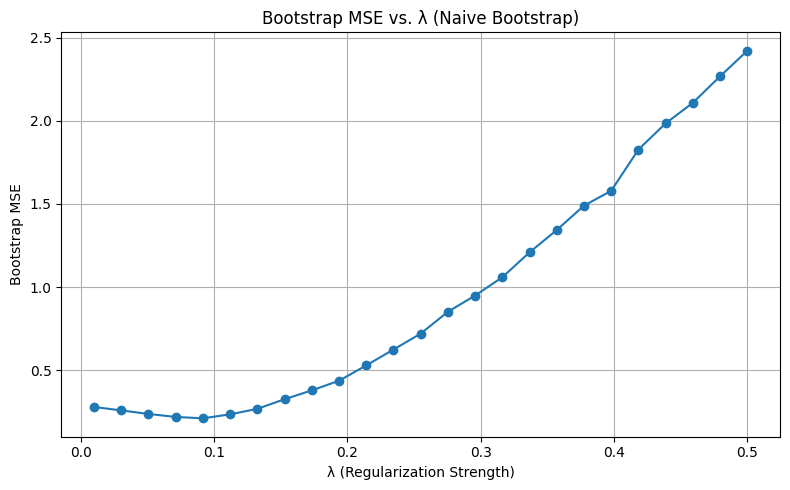

In [ ]:
import matplotlib.pyplot as plt
from dgp import DGP
from config import Config
from lasso_estimator import LassoEstimator
import numpy as np

# Settings
a_n = 0.25 * np.sqrt(np.log(Config.p) / Config.n)
lambda_grid = np.linspace(0.01, 0.5, 25)
B = 100  # Number of bootstrap replicates

# Generate a single replicate of data
dgp = DGP(signal_type="strong", error_type="gaussian", seed=999)
data = dgp.generate()

# Select lambda using naive bootstrap (no thresholding)
est = LassoEstimator()
_, mse_path = est.select_lambda_bootstrap_mse(
    X=data["X"], y=data["y"], lambdas=lambda_grid, B=B,
    a_n=a_n, method="naive"
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lambda_grid, mse_path, marker='o', linestyle='-')
plt.title("Bootstrap MSE vs. λ (Naive Bootstrap)")
plt.xlabel("λ (Regularization Strength)")
plt.ylabel("Bootstrap MSE")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from dgp import DGP
from config import Config
from lasso_estimator import LassoEstimator
from bootstraps.modified import ModifiedBootstrap

# Simulation settings
signal_type = "strong"
error_type = "gaussian"
lam_grid = np.linspace(0.05, 0.4, 5)
a_n = 0.25 * np.sqrt(np.log(Config.p) / Config.n)
B = 100  # small for test speed

# Generate data
dgp = DGP(signal_type=signal_type, error_type=error_type, seed=123)
data = dgp.generate()

# Fit initial Lasso estimator
estimator = LassoEstimator()
lam_star, _ = estimator.select_lambda_bootstrap_mse(data["X"], data["y"], lambdas=lam_grid, B=50, a_n=a_n)
estimator.fit(data["X"], data["y"], lam=lam_star, a_n=a_n, threshold=False)

# Instantiate and run modified bootstrap
mod_boot = ModifiedBootstrap(
    X=data["X"],
    y=data["y"],
    beta_hat=estimator.beta_hat,
    beta_true=data["beta"],
    a_n=a_n,
    standardize=True
)

results = mod_boot.generate_bootstrap_distribution(B=B, lam=lam_star, level=0.90)

# Diagnostics
print("🔁 Modified Bootstrap Summary:")
print("  Bootstrap mean (first 5):", results["mean"][:5])
print("  Std deviation (first 5):", results["std"][:5])
print("  CI lower (first 5):", results["ci_lower"][:5])
print("  CI upper (first 5):", results["ci_upper"][:5])
print("  CI length (first 5):", results["ci_length"][:5])
print("  Coverage (first 10):", results["coverage"][:10])


🔁 Modified Bootstrap Summary:
  Bootstrap mean (first 5): [-0.00684861  0.00026376  0.00158533 -0.00296634 -0.00185926]
  Std deviation (first 5): [0.01798861 0.01213228 0.01675747 0.01759141 0.01786008]
  CI lower (first 5): [-0.04066535 -0.00391942 -0.01206876 -0.0445069  -0.02463958]
  CI upper (first 5): [0.00000000e+00 8.32482415e-03 2.52729125e-02 3.01254370e-04
 5.70812494e-05]
  CI length (first 5): [0.04066535 0.01224425 0.03734167 0.04480816 0.02469666]
  Coverage (first 10): [1 1 1 1 1 0 1 1 1 1]


🔁 Wild Bootstrap Summary:
  λ*: 0.068
  Bootstrap mean (first 5): [-0.0069  0.0027 -0.0018 -0.0012 -0.0002]
  Std deviation (first 5): [0.0187 0.0196 0.0105 0.0078 0.0258]
  CI lower (first 5): [-0.055  -0.0021 -0.0001 -0.0146 -0.0379]
  CI upper (first 5): [0.     0.0177 0.     0.     0.0275]
  CI length (first 5): [0.055  0.0198 0.0001 0.0146 0.0654]
  Coverage (first 10): [1 1 1 1 1 0 1 1 1 1]


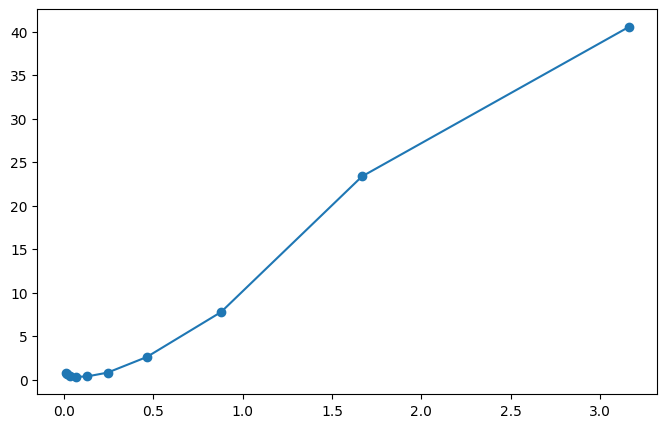

In [ ]:
from dgp import DGP
from config import Config
from lasso_estimator import LassoEstimator
from bootstraps.wild import WildBootstrap  # adjust path if needed

import numpy as np

# Configuration
signal_type = "strong"
error_type = "gaussian"

a_n = 0.25 * np.sqrt(np.log(Config.p) / Config.n)
lam_grid = np.logspace(-2, 0.5, 10)

# Generate data
dgp = DGP(signal_type=signal_type, error_type=error_type, seed=123)
data = dgp.generate()

# Fit LASSO and select λ* via wild-bootstrap-MSE
estimator = LassoEstimator()
lam_star, lam_path = estimator.select_lambda_bootstrap_mse(
    data["X"], data["y"], lambdas=lam_grid, B=50, a_n=a_n, method="wild"
)

# Fit final model
estimator.fit(data["X"], data["y"], lam=lam_star, a_n=a_n, threshold=False)

# Run wild bootstrap
wild = WildBootstrap(
    X=data["X"],
    y=data["y"],
    beta_hat=estimator.beta_hat,
    beta_true=data["beta"],
    a_n=a_n,
    standardize=True,
    seed=999
)

results = wild.generate_bootstrap_distribution(B=100, lam=lam_star, level=0.90)

# Print summary
print("🔁 Wild Bootstrap Summary:")
print("  λ*:", round(lam_star, 3))
print("  Bootstrap mean (first 5):", np.round(results["mean"][:5], 4))
print("  Std deviation (first 5):", np.round(results["std"][:5], 4))
print("  CI lower (first 5):", np.round(results["ci_lower"][:5], 4))
print("  CI upper (first 5):", np.round(results["ci_upper"][:5], 4))
print("  CI length (first 5):", np.round(results["ci_length"][:5], 4))
print("  Coverage (first 10):", results["coverage"][:10])
np.mean(np.count_nonzero(results["beta_star"], axis=1))
plt.hist(results["beta_star"][:, 1], bins=30)
plt.title("Distribution of β*_1 across wild bootstrap draws")
plt.plot(lam_grid, lam_path)
plt.xlabel("λ")
plt.ylabel("Bootstrap MSE")
plt.title("Wild Bootstrap: MSE(λ) Path")


Text(0.5, 1.0, 'Distribution of β*_1 across wild bootstrap draws')

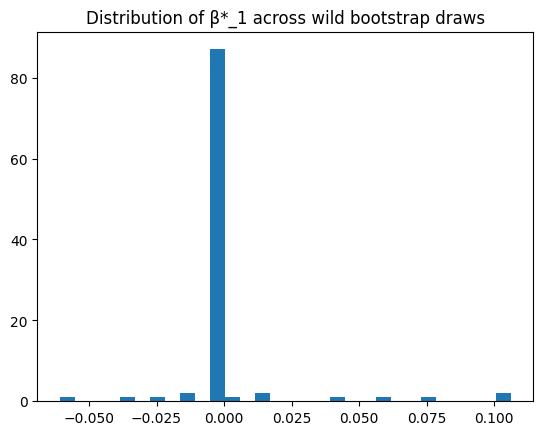

In [ ]:
plt.hist(results["beta_star"][:, 1], bins=30)
plt.title("Distribution of β*_1 across wild bootstrap draws")

In [ ]:
np.mean(np.count_nonzero(results["beta_star"], axis=1))

np.float64(60.6)

Text(0.5, 1.0, 'Wild Bootstrap: MSE(λ) Path')

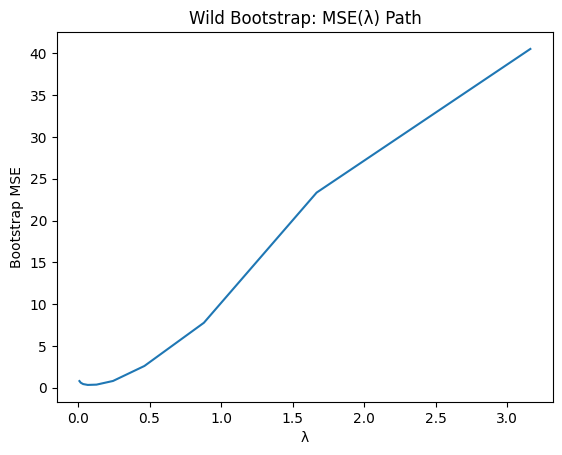

In [ ]:
plt.plot(lam_grid, lam_path)
plt.xlabel("λ")
plt.ylabel("Bootstrap MSE")
plt.title("Wild Bootstrap: MSE(λ) Path")

🔁 Block Bootstrap Summary:
  λ*: 0.036
  Bootstrap mean (first 5): [-0.0037  0.0038 -0.      0.     -0.0017]
  Std deviation (first 5): [0.0153 0.0166 0.0099 0.     0.0095]
  CI lower (first 5): [-0.0427  0.      0.      0.      0.    ]
  CI upper (first 5): [0.     0.0032 0.     0.     0.    ]
  CI length (first 5): [0.0427 0.0032 0.     0.     0.    ]
  Coverage (first 10): [1 1 1 1 1 0 1 1 1 1]
  Avg nonzero coefficients per draw: 44.04


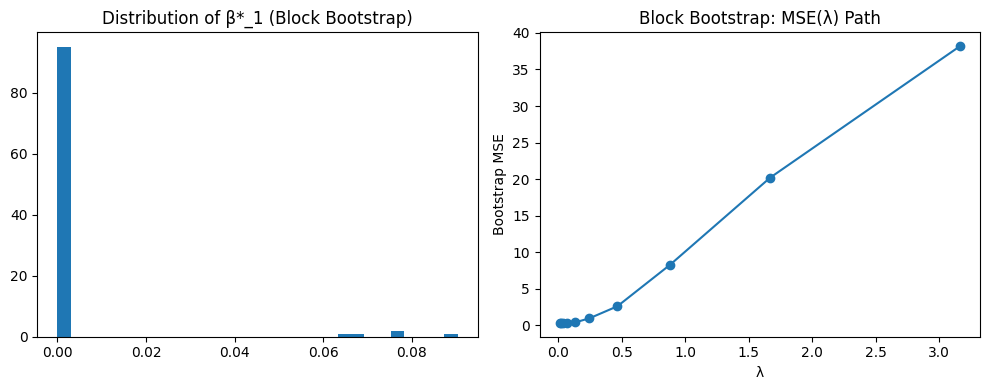

In [ ]:
from dgp import DGP
from config import Config
from lasso_estimator import LassoEstimator
from bootstraps.block import BlockBootstrap  # Adjust if stored elsewhere

import numpy as np
import matplotlib.pyplot as plt

# Configuration
signal_type = "strong"
error_type = "ar1"

a_n = 0.25 * np.sqrt(np.log(Config.p) / Config.n)
lam_grid = np.logspace(-2, 0.5, 10)
block_length = int(np.floor(Config.n ** (1 / 3)))

# Generate data
dgp = DGP(signal_type=signal_type, error_type=error_type, seed=100)
data = dgp.generate()

# Fit LASSO and select λ* via block-bootstrap-MSE
estimator = LassoEstimator()
lam_star, lam_path = estimator.select_lambda_bootstrap_mse(
    data["X"], data["y"],
    lambdas=lam_grid,
    B=50,
    a_n=a_n,
    method="block",
)

# Fit final model
estimator.fit(data["X"], data["y"], lam=lam_star, a_n=a_n, threshold=False)

# Run block bootstrap
block = BlockBootstrap(
    X=data["X"],
    y=data["y"],
    beta_hat=estimator.beta_hat,
    beta_true=data["beta"],
    a_n=a_n,
    block_size=block_length,
    standardize=True,
    seed=999
)

results = block.generate_bootstrap_distribution(B=100, lam=lam_star, level=0.90)

# Print summary
print("🔁 Block Bootstrap Summary:")
print("  λ*:", round(lam_star, 3))
print("  Bootstrap mean (first 5):", np.round(results["mean"][:5], 4))
print("  Std deviation (first 5):", np.round(results["std"][:5], 4))
print("  CI lower (first 5):", np.round(results["ci_lower"][:5], 4))
print("  CI upper (first 5):", np.round(results["ci_upper"][:5], 4))
print("  CI length (first 5):", np.round(results["ci_length"][:5], 4))
print("  Coverage (first 10):", results["coverage"][:10])

# Diagnostics
print("  Avg nonzero coefficients per draw:",
      np.mean(np.count_nonzero(results["beta_star"], axis=1)))

# Visuals
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(results["beta_star"][:, 1], bins=30)
plt.title("Distribution of β*_1 (Block Bootstrap)")

plt.subplot(1, 2, 2)
plt.plot(lam_grid, lam_path, marker='o')
plt.xlabel("λ")
plt.ylabel("Bootstrap MSE")
plt.title("Block Bootstrap: MSE(λ) Path")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from config import Config
from simulation import SimulationRunner  # Adjust if saved under another name

# Override config for a quick test
Config.num_mc = 2           # only 2 MC repetitions
Config.num_bootstrap = 50   # only 50 bootstrap draws
Config.set_random_seed(42)

# Narrow lambda grid for speed
lambda_grid = np.logspace(-3, 1, 50)
test_lambda_grid = np.logspace(-2, 0, 5)  # e.g., [0.01, 0.0316, ..., 1.0]

# Setup and run
runner = SimulationRunner(
    signal_type="strong",
    error_type="gaussian",
    bootstrap_methods=["naive", "modified", "wild", "block"],
    alpha_th_vals=[0.25, 0.5],  # one threshold level
    lambda_grid=test_lambda_grid,
    level=0.90
)

output = runner.run()

In [ ]:
from simulation import SimulationRunner
from config import Config
import numpy as np

# Config override for quick test
Config.num_mc = 2
Config.num_bootstrap = 50
Config.set_random_seed(42)

lambda_grid = np.logspace(-2, 0, 5)

runner = SimulationRunner(
    signal_type="strong",
    error_type="gaussian",
    bootstrap_methods=["naive", "modified", "wild", "block"],
    alpha_th_vals=[0.25],
    lambda_grid=lambda_grid,
    level=0.90
)

results = runner.run()

# Output DataFrames
summary_df = results["summary_df"]
raw_df = results["raw_df"]

# Print summary
print(summary_df.head())

   rep    method  alpha_th  lambda_star         snr  mean_coverage  \
0    0     naive      0.25          0.1  387.865344            0.2   
1    0  modified      0.25          0.1  387.865344            0.3   
2    0      wild      0.25          0.1  387.865344            0.3   
3    0     block      0.25          0.1  387.865344            0.3   
4    1     naive      0.25          0.1  387.865344            0.2   

   mean_ci_length  bias_hat  bias_tilde  var_boot_mean  mse_var_boot  \
0        0.195567 -0.034954   -0.034954       0.004110           0.0   
1        0.209173 -0.034954   -0.034954       0.004258           0.0   
2        0.207608 -0.034954   -0.034954       0.004497           0.0   
3        0.215751 -0.034954   -0.034954       0.004874           0.0   
4        0.195567 -0.034954   -0.034954       0.004110           0.0   

   support_size  perfect_match  
0            44          False  
1            44          False  
2            44          False  
3            4

In [ ]:
import numpy as np
from config import Config
from simulation import SimulationRunner

# Override for debugging
Config.num_mc = 50
Config.num_bootstrap = 50

# Run test simulation
runner = SimulationRunner(
    method="modified",
    alpha_th=0.25,
    signal_type="strong",
    error_type="gaussian",
    level=0.90,
    subdir="results/test_modified_strong_gaussian"
)

results = runner.run()
# summary_df = results["summary_df"]
# raw_df = results["raw_df"]

# print("Summary DF:")d
# print(summary_df.head())

# print("\nRaw DF:")
# print(raw_df.head())

In [ ]:
import numpy as np
from config import Config
from simulation import SimulationRunner

# Override for debugging
Config.num_mc = 50
Config.num_bootstrap = 50

# Run test simulation
runner = SimulationRunner(
    method="modified",
    alpha_th=0.25,
    signal_type="strong",
    error_type="ar1",
    level=0.90,
    subdir="results/test_modified_strong_ar1"
)

results = runner.run()

In [ ]:
import numpy as np
from config import Config
from simulation import SimulationRunner

# Override for debugging
Config.num_mc = 50
Config.num_bootstrap = 50

# Run test simulation
runner = SimulationRunner(
    method="block",
    alpha_th=0.25,
    signal_type="strong",
    error_type="gaussian",
    level=0.90,
    subdir="results/test_block_strong_gaussian"
)

results = runner.run()

In [ ]:
import numpy as np
from config import Config
from simulation import SimulationRunner

# Override for debugging
Config.num_mc = 50
Config.num_bootstrap = 50

# Run test simulation
runner = SimulationRunner(
    method="modified",
    alpha_th=0.25,
    signal_type="weak",
    error_type="gaussian",
    level=0.90,
    subdir="results/test_modified_weak_gaussian"
)

results = runner.run()

In [ ]:
from SimulationTables import generate_summary_tables
import numpy as np
from config import Config
from simulation import SimulationRunner

runner = SimulationRunner("modified", lambda_val=0.1, threshold_val=0.25*np.sqrt(np.log(Config.p)/Config.n), signal_type="strong", error_type="gaussian")
results = runner.run()

tables = generate_summary_tables(results["summary_df"], results["pointwise_variance_df"])


In [ ]:
print(results["summary_df"].columns)

Index(['rep', 'method', 'lambda_val', 'threshold_val', 'snr', 'mean_coverage',
       'mean_ci_length', 'bias_hat', 'bias_tilde', 'var_boot_mean',
       'mse_var_boot', 'support_size', 'perfect_match', 'jaccard', 'fdr',
       'fnr', 'precision', 'recall'],
      dtype='object')


In [ ]:
print("Summary Table:")
print(tables["summary_table"].head())
print("\nPointwise Variance Table:")
print(tables["pointwise_variance_table"].head())
print("\nCoverage Table:")
print(tables["coverage_table"].head())
print("\nBootstrap MSE Table:")
print(tables["bootstrap_mse_table"].head())



Summary Table:


KeyError: 'summary_table'

In [ ]:
for name, df in tables.items():
    print(f"\n==== {name.upper()} TABLE ====")
    print(df.head(10))


==== COVERAGE TABLE ====
method                    modified
lambda_val threshold_val          
0.1        0.042219          0.197

==== CI_LENGTH TABLE ====
method                    modified
lambda_val threshold_val          
0.1        0.042219       0.230276

==== SUPPORT_RECOVERY TABLE ====
                               fdr      fnr   jaccard precision   recall  \
method                    modified modified  modified  modified modified   
lambda_val threshold_val                                                   
0.1        0.042219       0.765393      0.0  0.234607  0.234607      1.0   

                         support_size  
method                       modified  
lambda_val threshold_val               
0.1        0.042219             43.25  

==== VARIANCE_FIDELITY TABLE ====
                                    boot_variance_mean mc_variance  \
method                                        modified    modified   
beta_index lambda_val threshold_val                            

SNR: 336.80989662415647
Support Size (est): 11
Perfect Match: False
Tracked Indices CI Coverage:
  β_5: MISS | CI = [4.4211, 4.7990] | β_j = 5.0000
  β_20: MISS | CI = [-3.5456, -3.1734] | β_j = -4.0000


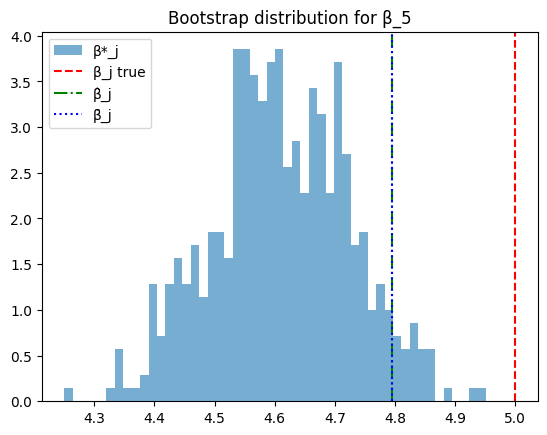

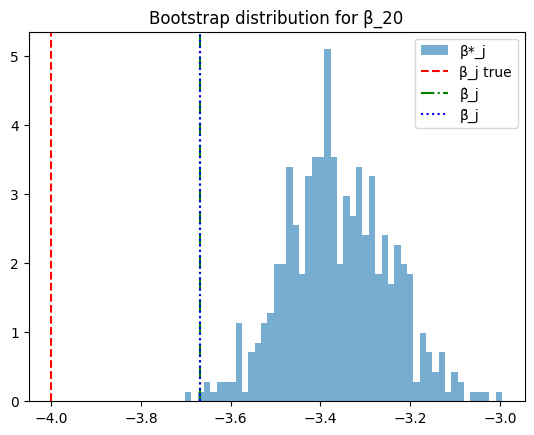


=== BOOTSTRAP DIAGNOSTICS FOR METHOD: modified ===

--- β_5 ---
β_true       = 5.0000
β_hat        = 4.7958  (bias = -0.2042)
β_tilde      = 4.7958  (bias = -0.2042)
Boot Mean    = 4.6102
Boot Std     = 0.1143
CI Lower     = 4.4211
CI Upper     = 4.7990
CI Width     = 0.3779
Contains β?  = NO
q_0.05 / q_0.95 = 4.4211 / 4.7990
q_0.025 / q_0.975 = 4.3957 / 4.8312

--- β_20 ---
β_true       = -4.0000
β_hat        = -3.6692  (bias = 0.3308)
β_tilde      = -3.6692  (bias = 0.3308)
Boot Mean    = -3.3613
Boot Std     = 0.1157
CI Lower     = -3.5456
CI Upper     = -3.1734
CI Width     = 0.3722
Contains β?  = NO
q_0.05 / q_0.95 = -3.5456 / -3.1734
q_0.025 / q_0.975 = -3.5827 / -3.1330


In [ ]:
from simulation import SingleSimulationRun  # if you saved it as such
import numpy as np

# Set bootstrap replicates and MC repetitions appropriately
from config import Config
Config.num_bootstrap = 500
Config.num_mc = 1
Config.seed = 123  # for reproducibility

# Set λ and α_th manually
lambda_val = 0.25
alpha_th = 5
threshold_val = alpha_th * np.sqrt(np.log(Config.p) / Config.n)

# Run 1 replication
sim = SingleSimulationRun(
    method="modified",
    lambda_val=lambda_val,
    threshold_val=threshold_val,
    signal_type="strong",
    error_type="gaussian",
    tracked_indices=[5, 20]
)

results = sim.run()

# Print basic diagnostics
print("SNR:", results["snr"])
print("Support Size (est):", results["support_size"])
print("Perfect Match:", results["perfect_match"])
print("Tracked Indices CI Coverage:")
for j in results["tracked_indices"]:
    covered = results["coverage"][j]
    print(f"  β_{j}: {'COVERED' if covered else 'MISS'} | CI = [{results['ci_lower'][j]:.4f}, {results['ci_upper'][j]:.4f}] | β_j = {results['beta_true'][j]:.4f}")

# Optional: inspect beta_star distribution manually
import matplotlib.pyplot as plt
for j in results["tracked_indices"]:
    plt.figure()
    plt.hist(results["beta_star"][:, j], bins=50, density=True, alpha=0.6, label='β*_j')
    plt.axvline(results["beta_true"][j], color='r', linestyle='--', label='β_j true')
    plt.axvline(results["beta_hat"][j], color='g', linestyle='-.', label='β̂_j')
    plt.axvline(results["beta_tilde"][j], color='b', linestyle=':', label='β̃_j')
    plt.title(f"Bootstrap distribution for β_{j}")
    plt.legend()
    plt.show()


print(f"\n=== BOOTSTRAP DIAGNOSTICS FOR METHOD: {results['method']} ===")
for j in results["tracked_indices"]:
    print(f"\n--- β_{j} ---")
    beta_j = results["beta_true"][j]
    hat_j = results["beta_hat"][j]
    tilde_j = results["beta_tilde"][j]
    boot_j = results["beta_star"][:, j]
    lower, upper = results["ci_lower"][j], results["ci_upper"][j]
    coverage = results["coverage"][j]

    print(f"β_true       = {beta_j:.4f}")
    print(f"β_hat        = {hat_j:.4f}  (bias = {hat_j - beta_j:.4f})")
    print(f"β_tilde      = {tilde_j:.4f}  (bias = {tilde_j - beta_j:.4f})")
    print(f"Boot Mean    = {np.mean(boot_j):.4f}")
    print(f"Boot Std     = {np.std(boot_j):.4f}")
    print(f"CI Lower     = {lower:.4f}")
    print(f"CI Upper     = {upper:.4f}")
    print(f"CI Width     = {upper - lower:.4f}")
    print(f"Contains β?  = {'YES' if coverage else 'NO'}")
    print(f"q_0.05 / q_0.95 = {np.quantile(boot_j, 0.05):.4f} / {np.quantile(boot_j, 0.95):.4f}")
    print(f"q_0.025 / q_0.975 = {np.quantile(boot_j, 0.025):.4f} / {np.quantile(boot_j, 0.975):.4f}")



=== Global Summary ===
Method: modified
Lambda: 0.1000, Threshold: 0.0422
SNR: 336.81
Support Size (est): 37
Precision: 0.270, Recall: 1.000, FDR: 0.730
Jaccard Index: 0.270
Avg CI Width (support): 0.2198
Mean Abs Bias (support): 0.1929
Coverage Rate (support): 0.200

--- β_5 ---
β_true       = 5.0000
β_hat        = 4.8352  (bias = -0.1648)
β_tilde      = 4.8352  (bias = -0.1648)
Boot Mean    = 4.7805
Boot Std     = 0.0661
Boot Bias    = -0.0547
CI Lower     = 4.6707
CI Upper     = 4.8809
CI Width     = 0.2102
Contains β?  = NO


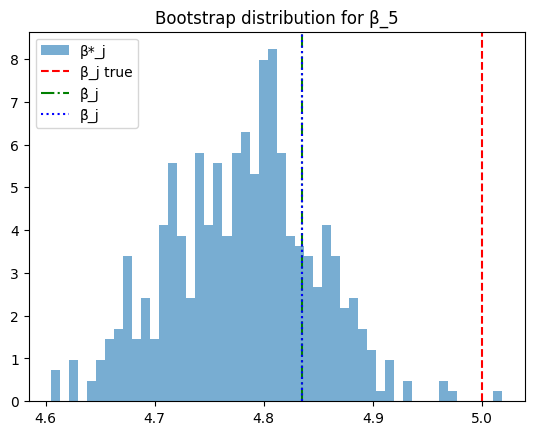


--- β_20 ---
β_true       = -4.0000
β_hat        = -3.8279  (bias = 0.1721)
β_tilde      = -3.8279  (bias = 0.1721)
Boot Mean    = -3.6950
Boot Std     = 0.0689
Boot Bias    = 0.1329
CI Lower     = -3.8037
CI Upper     = -3.5825
CI Width     = 0.2212
Contains β?  = NO


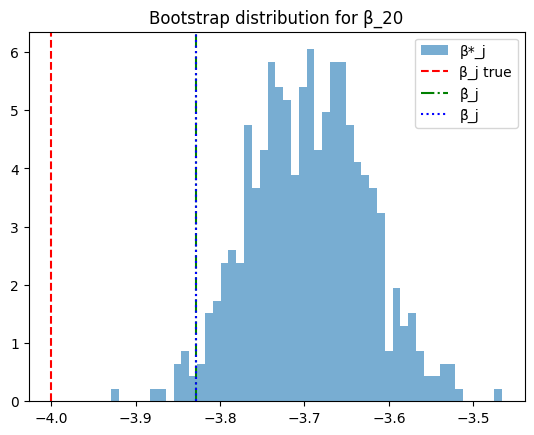

In [ ]:
from simulation import SingleSimulationRun  # adjust if needed
from config import Config
import numpy as np
import matplotlib.pyplot as plt

# Setup parameters
Config.seed = 123
Config.num_bootstrap = 500
Config.num_mc = 1  # Just for context; not used here

lambda_val = 0.1
alpha_th = 0.25
threshold_val = alpha_th * np.sqrt(np.log(Config.p) / Config.n)

sim = SingleSimulationRun(
    method="modified",
    lambda_val=lambda_val,
    threshold_val=threshold_val,
    signal_type="strong",
    error_type="gaussian",
    tracked_indices=[5, 20]
)

results = sim.run()

# Print global summary
print(f"\n=== Global Summary ===")
print(f"Method: {results['method']}")
print(f"Lambda: {results['lambda_val']:.4f}, Threshold: {results['threshold_val']:.4f}")
print(f"SNR: {results['snr']:.2f}")
print(f"Support Size (est): {results['support_size']}")
print(f"Precision: {results['precision']:.3f}, Recall: {results['recall']:.3f}, FDR: {results['fdr']:.3f}")
print(f"Jaccard Index: {results['jaccard']:.3f}")
print(f"Avg CI Width (support): {results['avg_ci_width_support']:.4f}")
print(f"Mean Abs Bias (support): {results['mean_abs_bias_support']:.4f}")
print(f"Coverage Rate (support): {results['coverage_rate_support']:.3f}")

# Per-j diagnostics
for j in results["tracked_indices"]:
    print(f"\n--- β_{j} ---")
    print(f"β_true       = {results['beta_true'][j]:.4f}")
    print(f"β_hat        = {results['beta_hat'][j]:.4f}  (bias = {results['bias_hat'][j]:.4f})")
    print(f"β_tilde      = {results['beta_tilde'][j]:.4f}  (bias = {results['bias_tilde'][j]:.4f})")
    print(f"Boot Mean    = {np.mean(results['beta_star'][:, j]):.4f}")
    print(f"Boot Std     = {np.std(results['beta_star'][:, j]):.4f}")
    print(f"Boot Bias    = {results['boot_bias'][j]:.4f}")
    print(f"CI Lower     = {results['ci_lower'][j]:.4f}")
    print(f"CI Upper     = {results['ci_upper'][j]:.4f}")
    print(f"CI Width     = {results['ci_length'][j]:.4f}")
    print(f"Contains β?  = {'YES' if results['coverage'][j] else 'NO'}")

    # Plot distribution
    plt.figure()
    plt.hist(results["beta_star"][:, j], bins=50, density=True, alpha=0.6, label='β*_j')
    plt.axvline(results["beta_true"][j], color='r', linestyle='--', label='β_j true')
    plt.axvline(results["beta_hat"][j], color='g', linestyle='-.', label='β̂_j')
    plt.axvline(results["beta_tilde"][j], color='b', linestyle=':', label='β̃_j')
    plt.title(f"Bootstrap distribution for β_{j}")
    plt.legend()
    plt.show()


=== GLOBAL DIAGNOSTICS ===
Method: modified
λ = 0.1000, α_th = 0.25, Threshold = 0.0422
SNR: 336.81
Support size: 37
Precision: 0.270, Recall: 1.000, FDR: 0.730
Jaccard index: 0.270
Avg. CI width (support): 0.2599
Mean abs bias (support): 0.1929
Coverage rate (support): 0.200
Coverage rate (nulls): 1.000

=== CI Quantiles & Asymmetry ===
       q_025     q_975      q_05      q_95
5   4.655393  4.897087  4.670735  4.880937
22  0.000000  0.029997  0.000000  0.009311

Tail Asymmetry (tracked):
β_5: -0.0085
β_22: 0.0271

=== β_5 DETAILS ===
β_true       = 5.0000
β_hat        = 4.8352  (bias = -0.1648)
β_tilde      = 4.8352  (bias = -0.1648)
Boot Mean    = 4.7805
Boot Std     = 0.0661
Boot Bias    = -0.0547
CI Lower     = 4.6554
CI Upper     = 4.8971
CI Width     = 0.2417
Contains β?  = NO


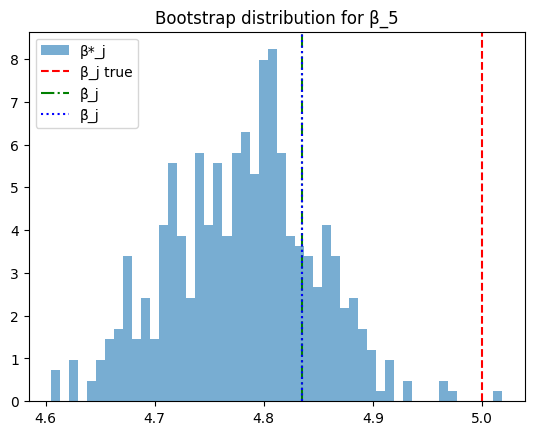


=== β_22 DETAILS ===
β_true       = 0.0000
β_hat        = -0.0000  (bias = -0.0000)
β_tilde      = -0.0000  (bias = -0.0000)
Boot Mean    = 0.0015
Boot Std     = 0.0085
Boot Bias    = 0.0015
CI Lower     = 0.0000
CI Upper     = 0.0300
CI Width     = 0.0300
Contains β?  = YES


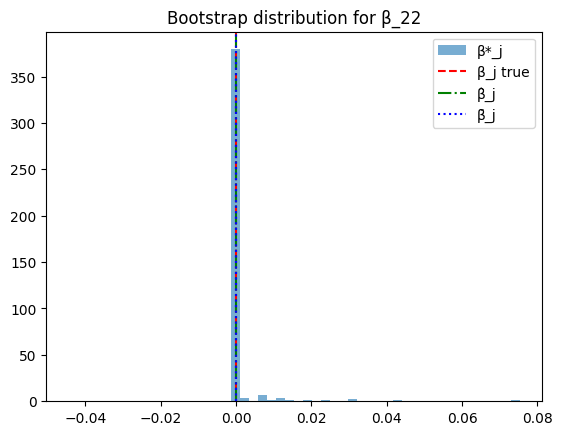

In [ ]:
from simulation import SingleSimulationRun  # use your correct import path
from config import Config
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Setup
Config.seed = 123
Config.num_bootstrap = 500
Config.num_mc = 1

lambda_val = 0.1
alpha_th = 0.25
threshold_val = alpha_th * np.sqrt(np.log(Config.p) / Config.n)

sim = SingleSimulationRun(
    method="modified",
    lambda_val=lambda_val,
    threshold_val=threshold_val,
    signal_type="strong",
    error_type="gaussian",
    tracked_indices=[5, 22]
)

results = sim.run()

# Summary block
print("\n=== GLOBAL DIAGNOSTICS ===")
print(f"Method: {results['method']}")
print(f"λ = {results['lambda_val']:.4f}, α_th = {alpha_th}, Threshold = {results['threshold_val']:.4f}")
print(f"SNR: {results['snr']:.2f}")
print(f"Support size: {results['support_size']}")
print(f"Precision: {results['precision']:.3f}, Recall: {results['recall']:.3f}, FDR: {results['fdr']:.3f}")
print(f"Jaccard index: {results['jaccard']:.3f}")
print(f"Avg. CI width (support): {results['avg_ci_width_support']:.4f}")
print(f"Mean abs bias (support): {results['mean_abs_bias_support']:.4f}")
print(f"Coverage rate (support): {results['coverage_rate_support']:.3f}")
print(f"Coverage rate (nulls): {results['null_coverage_rate']:.3f}")

# Quantile and tail asymmetry diagnostics
print("\n=== CI Quantiles & Asymmetry ===")
df_q = pd.DataFrame(results["ci_quantiles"])
print(df_q.loc[results['tracked_indices']])

print("\nTail Asymmetry (tracked):")
for j in results["tracked_indices"]:
    print(f"β_{j}: {results['tail_asymmetry'][j]:.4f}")

# Tracked index diagnostics
for j in results["tracked_indices"]:
    print(f"\n=== β_{j} DETAILS ===")
    print(f"β_true       = {results['beta_true'][j]:.4f}")
    print(f"β_hat        = {results['beta_hat'][j]:.4f}  (bias = {results['bias_hat'][j]:.4f})")
    print(f"β_tilde      = {results['beta_tilde'][j]:.4f}  (bias = {results['bias_tilde'][j]:.4f})")
    print(f"Boot Mean    = {np.mean(results['beta_star'][:, j]):.4f}")
    print(f"Boot Std     = {np.std(results['beta_star'][:, j]):.4f}")
    print(f"Boot Bias    = {results['boot_bias'][j]:.4f}")
    print(f"CI Lower     = {results['ci_lower'][j]:.4f}")
    print(f"CI Upper     = {results['ci_upper'][j]:.4f}")
    print(f"CI Width     = {results['ci_length'][j]:.4f}")
    print(f"Contains β?  = {'YES' if results['coverage'][j] else 'NO'}")

    plt.figure()
    plt.hist(results["beta_star"][:, j], bins=50, density=True, alpha=0.6, label='β*_j')
    plt.axvline(results["beta_true"][j], color='r', linestyle='--', label='β_j true')
    plt.axvline(results["beta_hat"][j], color='g', linestyle='-.', label='β̂_j')
    plt.axvline(results["beta_tilde"][j], color='b', linestyle=':', label='β̃_j')
    plt.title(f"Bootstrap distribution for β_{j}")
    plt.legend()
    plt.show()


In [ ]:
import numpy as np
from config import Config
from dgp import DGP
from LassoEstimatorTheory import LassoEstimatorTheory

def compute_lambda_alpha_grid(signal_type, error_type, num_lambdas=3, alpha_grid=[0.125, 0.25, 0.75]):
    # 1. Generate one DGP draw to base the grid on
    dgp = DGP(signal_type=signal_type, error_type=error_type, seed=Config.seed)
    data = dgp.generate()
    X, y, beta_true, support_true, snr = data["X"], data["y"], data["beta"], data["support"], data["snr"]

    # 2. Fit Lasso with cross-validated or fixed λ (use theory-based λ for now)
    estimator = LassoEstimatorTheory()
    rough_lambda = 0.5 * np.sqrt(np.log(Config.p) / Config.n)  # placeholder; you could tune this too
    estimator.fit(X, y, lam=rough_lambda, thresholding_level=0.0, apply_threshold=False, support_true=support_true)
    
    beta_hat = estimator.beta_hat.copy()

    # 3. Estimate sigma from residuals
    residuals = estimator.residuals
    sigma_hat = np.std(residuals)

    # 4. Theoretical lambda base
    lambda_base = sigma_hat * np.sqrt(np.log(Config.p) / Config.n)
    lambda_grid = np.round(np.linspace(0.5, 2.0, num_lambdas) * lambda_base, 5)

    # 5. Alpha threshold (based on nulls)
    null_indices = list(set(range(Config.p)) - set(support_true))
    null_magnitudes = np.abs(beta_hat[null_indices])
    threshold_95 = np.quantile(null_magnitudes, 0.95)
    alpha_null = threshold_95 / np.sqrt(np.log(Config.p) / Config.n)

    # 6. Final α grid includes theory + data-informed
    alpha_grid = sorted(set(alpha_grid + [round(alpha_null, 3)]))

    return {
        "lambda_grid": lambda_grid.tolist(),
        "alpha_grid": alpha_grid,
        "sigma_hat": sigma_hat,
        "lambda_base": lambda_base,
        "alpha_null": round(alpha_null, 3),
        "support": support_true,
        "snr": snr
    }

# Store in a global dictionary
PRECOMPUTED_GRIDS = {}
for signal in ["strong", "weak", "nearzero"]:
    for error in ["gaussian", "heteroskedastic", "ar1"]:
        key = (signal, error)
        PRECOMPUTED_GRIDS[key] = compute_lambda_alpha_grid(signal, error)

# Display example
from pprint import pprint
pprint(PRECOMPUTED_GRIDS[("strong", "gaussian")])


{'alpha_grid': [0.125, np.float64(0.199), 0.25, 0.75],
 'alpha_null': np.float64(0.199),
 'lambda_base': np.float64(0.13122955433305397),
 'lambda_grid': [0.06561, 0.16404, 0.26246],
 'sigma_hat': np.float64(0.7770790034172057),
 'snr': np.float64(387.8653436063328),
 'support': [5, 20, 45, 70, 100, 130, 160, 200, 240, 280]}


In [ ]:
import numpy as np
from config import Config
from dgp import DGP
from LassoEstimatorTheory import LassoEstimatorTheory
from pprint import pprint

def compute_lambda_alpha_grid(signal_type, error_type, num_lambdas=3):
    # 1. Generate one DGP draw to base the grid on
    dgp = DGP(signal_type=signal_type, error_type=error_type, seed=Config.seed)
    data = dgp.generate()
    X, y, beta_true, support_true, snr = data["X"], data["y"], data["beta"], data["support"], data["snr"]

    # 2. Fit Lasso with fixed λ (theory-based)
    estimator = LassoEstimatorTheory()
    rough_lambda = 0.5 * np.sqrt(np.log(Config.p) / Config.n)
    estimator.fit(X, y, lam=rough_lambda, thresholding_level=0.0, apply_threshold=False, support_true=support_true)
    
    beta_hat = estimator.beta_hat.copy()

    # 3. Estimate sigma from residuals
    residuals = estimator.residuals
    sigma_hat = np.std(residuals)

    # 4. Theoretical lambda base
    lambda_base = sigma_hat * np.sqrt(np.log(Config.p) / Config.n)
    lambda_grid = np.round(np.array([0.5, 1.0, 2.0]) * lambda_base, 5)

    # 5. Alpha threshold (based on 95% quantile of nulls)
    null_indices = list(set(range(Config.p)) - set(support_true))
    null_magnitudes = np.abs(beta_hat[null_indices])
    threshold_95 = np.quantile(null_magnitudes, 0.95)
    alpha_null = threshold_95 / np.sqrt(np.log(Config.p) / Config.n)

    # 6. Alpha grid based on alpha_null
    alpha_grid = [round(alpha_null * factor, 3) for factor in [0.5, 1.0, 2.0]]

    return {
        "lambda_base": lambda_base,
        "lambda_grid": lambda_grid.tolist(),
        "alpha_null": round(alpha_null, 3),
        "alpha_grid": alpha_grid,
        "sigma_hat": sigma_hat,
        # "support": support_true,
        "snr": snr
    }

# Compute and return results for all 9 configurations
configurations = {}
for signal in ["strong", "weak", "nearzero"]:
    for error in ["gaussian", "heteroskedastic", "ar1"]:
        key = (signal, error)
        configurations[key] = compute_lambda_alpha_grid(signal, error)

configurations[("strong", "gaussian")]  # Example output to verify

pprint(configurations)

{('nearzero', 'ar1'): {'alpha_grid': [np.float64(0.101),
                                      np.float64(0.202),
                                      np.float64(0.403)],
                       'alpha_null': np.float64(0.202),
                       'lambda_base': np.float64(0.13535487602292262),
                       'lambda_grid': [0.06768, 0.13535, 0.27071],
                       'sigma_hat': np.float64(0.8015071963180411),
                       'snr': np.float64(11.178866835147632)},
 ('nearzero', 'gaussian'): {'alpha_grid': [np.float64(0.109),
                                           np.float64(0.218),
                                           np.float64(0.436)],
                            'alpha_null': np.float64(0.218),
                            'lambda_base': np.float64(0.1306681855715374),
                            'lambda_grid': [0.06533, 0.13067, 0.26134],
                            'sigma_hat': np.float64(0.7737548446180245),
                            'snr': 

In [1]:
from MonteCarloRunner import MonteCarloRunner # if stored externally
from pprint import pprint
import numpy as np

# Step 1: Extract grid values for ("strong", "gaussian")
# config = PRECOMPUTED_GRIDS[("strong", "gaussian")]
# lambda_val = configurations[("strong", "gaussian")]["lambda_grid"][1]      # First lambda (0.5 × base)
# threshold_val = configurations[("strong", "gaussian")]["alpha_grid"][1]         # First alpha (0.5 × null-based)

lambda_val = 0.13123
threshold_val = 0.199
# Step 2: Compute threshold value
# threshold_val = alpha_th * np.sqrt(np.log(Config.p) / Config.n)

# Step 3: Run the Monte Carlo simulation (test run with R = 10)
runner = MonteCarloRunner(
    method="modified",
    lambda_val=lambda_val,
    threshold_val=threshold_val,
    signal_type="strong",
    error_type="gaussian",
    level=0.90,
    tracked_indices=[5, 22],
    R=10
)

results = runner.run()

# Step 4: Print summary
print("=== Aggregated Summary ===")
pprint(results["summary"])

# Step 5: Tracked diagnostics (for j=5 and j=20)
for j, metrics in results["tracked"].items():
    print(f"\n=== Tracked Metrics for β_{j} ===")
    for k, v in metrics.items():
        print(f"{k}: mean = {np.mean(v):.4f}, std = {np.std(v):.4f}")


Running simulation 1/10 with seed 42
Running simulation with seed 42 for method modified
Running simulation 2/10 with seed 43
Running simulation with seed 43 for method modified
Running simulation 3/10 with seed 44
Running simulation with seed 44 for method modified
Running simulation 4/10 with seed 45
Running simulation with seed 45 for method modified
Running simulation 5/10 with seed 46
Running simulation with seed 46 for method modified
Running simulation 6/10 with seed 47
Running simulation with seed 47 for method modified
Running simulation 7/10 with seed 48
Running simulation with seed 48 for method modified
Running simulation 8/10 with seed 49
Running simulation with seed 49 for method modified
Running simulation 9/10 with seed 50
Running simulation with seed 50 for method modified
Running simulation 10/10 with seed 51
Running simulation with seed 51 for method modified
=== Aggregated Summary ===
{'ci_width_support': np.float64(0.2606514046845475),
 'coverage_null': np.float64(

In [16]:
import numpy as np
from config import Config
from simulation import SingleSimulationRun

# === Config for CL-style low p/n regime ===
config = Config(p=10, n=250, seed=234)
lambda_val = 0.0915783
threshold_val = 0.531  

# === Run the simulation ===
sim = SingleSimulationRun(
    method="modified",
    lambda_val=lambda_val,
    threshold_val=threshold_val,
    signal_type="strong",
    error_type="gaussian",
    config=config,
    level=0.90,
    tracked_indices=list(range(config.s))
)
result = sim.run()

# === Per-component CI diagnostics ===
print("\n=== PER-COEFFICIENT CI CHECK (MODIFIED BOOTSTRAP) ===")
support = result["support_true"]
for j in support:
    beta_j = result["beta_true"][j]
    ci_l, ci_u = result["ci_lower"][j], result["ci_upper"][j]
    bias = result["bias_hat"][j]
    std = np.std(result["beta_star"][:, j])
    contains = ci_l <= beta_j <= ci_u

    print(f"\n--- j = {j} ---")
    print(f"β_true       = {beta_j:.4f}")
    print(f"CI           = [{ci_l:.4f}, {ci_u:.4f}]")
    print(f"→ Contains β? {'YES' if contains else 'NO'}")
    print(f"→ Bias(β̂)    = {bias:.4f}")
    print(f"→ Boot STD   = {std:.5f}")
    print(f"→ CI Width   = {ci_u - ci_l:.4f}")
    print(f"→ Boot Mean  = {np.mean(result['beta_star'][:, j]):.4f}")
    print(f"→ Threshold  = {result['threshold_val']:.5f}")


Running simulation with seed: 234

=== PER-COEFFICIENT CI CHECK (MODIFIED BOOTSTRAP) ===

--- j = 0 ---
β_true       = 5.0000
CI           = [4.9070, 5.1192]
→ Contains β? YES
→ Bias(β̂)    = -0.0829
→ Boot STD   = 0.06648
→ CI Width   = 0.2122
→ Boot Mean  = 4.8202
→ Threshold  = 0.53100

--- j = 1 ---
β_true       = -4.0000
CI           = [-4.0216, -3.7990]
→ Contains β? YES
→ Bias(β̂)    = 0.1660
→ Boot STD   = 0.06927
→ CI Width   = 0.2226
→ Boot Mean  = -3.7541
→ Threshold  = 0.53100

--- j = 2 ---
β_true       = 10.0000
CI           = [9.8677, 10.0792]
→ Contains β? YES
→ Bias(β̂)    = -0.1080
→ Boot STD   = 0.06562
→ CI Width   = 0.2114
→ Boot Mean  = 9.8123
→ Threshold  = 0.53100

--- j = 3 ---
β_true       = -6.0000
CI           = [-6.0958, -5.8742]
→ Contains β? YES
→ Bias(β̂)    = 0.0912
→ Boot STD   = 0.06504
→ CI Width   = 0.2216
→ Boot Mean  = -5.8363
→ Threshold  = 0.53100

--- j = 4 ---
β_true       = 2.0000
CI           = [1.8680, 2.0705]
→ Contains β? YES
→ Bias(β̂)  

In [13]:
import numpy as np
from config import Config
from simulation import SingleSimulationRun

config = Config(p=10, n=250, seed=42)
lambda_val = 0.0915783
threshold_val = 0.531  

# 3. Create and run simulation object
sim = SingleSimulationRun(
    method="modified",
    lambda_val=lambda_val,
    threshold_val=threshold_val,
    signal_type="strong",            # or "cl_example" if you have a preset DGP
    error_type="gaussian",
    config=config,
    level=0.90,
    tracked_indices=[0, 1, 2, 3, 4]   # track first 5 support indices
)

results = sim.run()

Running simulation with seed: 42


In [3]:
from dgp import DGP
from sklearn.linear_model import Lasso
from config import Config

# 1) Generate data
dgp = DGP(config=Config, signal_type="strong", error_type="gaussian")
data = dgp.generate()
X, y, beta_true = data["X"], data["y"], data["beta"]

# 2) Fit initial Lasso to get β̂
lam = 0.1  # ← set your λₙ here
initial_model = Lasso(alpha=lam, fit_intercept=False, max_iter=10000)
initial_model.fit(X, y)
beta_hat = initial_model.coef_

# 3) Set threshold a_n = n^(−1/3)
a_n = config.n ** (-1/3)

# 4) Run the modified residual bootstrap
mb = ModifiedBootstrap(
    X, y, beta_hat, beta_true,
    a_n=a_n,
    fit_intercept=False,
    seed=123
)
results = mb.generate_bootstrap_distribution(
    B=500,
    lam=lam,
    level=0.90
)

# 5) Quick check of coverage
print("Avg. coverage over Δ≠0 coords:", results["coverage"][beta_true!=0].mean())


AttributeError: type object 'Config' has no attribute 'n'

In [ ]:
from dgp import DGP
from sklearn.linear_model import Lasso
from config import Config
from simulation import SingleSimulationRun 


config = Config(p=10, n=250, seed=233)
lambda_val = 0.0915783
threshold_val = 0.531  

# 3. Create and run simulation object
sim = SingleSimulationRun(
    method="modified",
    lambda_val=lambda_val,
    threshold_val=threshold_val,
    signal_type="strong",            # or "cl_example" if you have a preset DGP
    error_type="gaussian",
    config=config,
    level=0.90,
    tracked_indices=[0, 1, 2, 3, 4]   # track first 5 support indices
)

results = sim.run()

Running simulation with seed: 233


In [ ]:
from config import Config
from MonteCarloRunner import MonteCarloRunner

# 1) Set up your config (make sure it has num_bootstrap and num_mc attributes)
config = Config(
    p=50,
    n=250,
    seed=233,         
)

lambda_val    = 0.1152
threshold_val = 0.3139

# 2) Instantiate and run the MC runner
mc_runner = MonteCarloRunner(
    method="naive",
    lambda_val=lambda_val,
    threshold_val=threshold_val,
    signal_type="strong",
    error_type="gaussian",
    config=config,
    level=0.90,
    tracked_indices=[0, 1, 2, 3, 4],
    R=100   # override default if you like; here we do 500 MC runs
)

mc_results = mc_runner.run()

# 3) Extract and print the coverage metrics
cover_support = mc_results["summary"]["coverage_support"]
cover_null    = mc_results["summary"]["coverage_null"]
cover_overall = mc_results["summary"]["coverage_overall"]

print(f"Support coverage (true nonzeros):  {cover_support:.3f}")
print(f"Null coverage   (true zeros):      {cover_null:.3f}")
print(f"Overall coverage (all coords):     {cover_overall:.3f}")

# 4) (Optional) inspect the full summary
print("\nFull summary:")
for k, v in mc_results["summary"].items():
    print(f"  {k:25s}: {v}")


Support coverage (true nonzeros):  0.847
Null coverage   (true zeros):      0.925
Overall coverage (all coords):     0.894

Full summary:
  method                   : naive
  lambda_val               : 0.0915783
  threshold_val            : 0.531
  signal_type              : weak
  error_type               : gaussian
  coverage_support         : 0.8470000000000002
  coverage_null            : 0.9246666666666669
  coverage_overall         : 0.8936
  ci_width_support         : 0.21281479954404545
  mean_abs_bias            : 0.0985187410114253
  precision                : 0.8346963869463869
  recall                   : 0.996
  fdr                      : 0.16530361305361307
  jaccard                  : 0.8319376456876456
  snr                      : 26.10244537843823
  boot_var_support         : 0.00422664372746906
  boot_bias_support        : -0.04647494180859554
  tail_asym_support        : 0.1857025031426769
  stable_support_avg_size  : 9.25


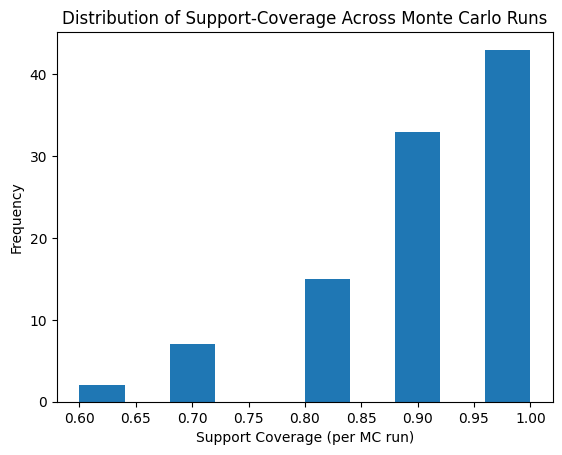

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the per-run support coverage values
cover_support = np.array([run["coverage_support"] for run in mc_results["raw_runs"]])

# Plot histogram
plt.figure()
plt.hist(cover_support, bins=10)
plt.xlabel("Support Coverage (per MC run)")
plt.ylabel("Frequency")
plt.title("Distribution of Support‐Coverage Across Monte Carlo Runs")
plt.show()

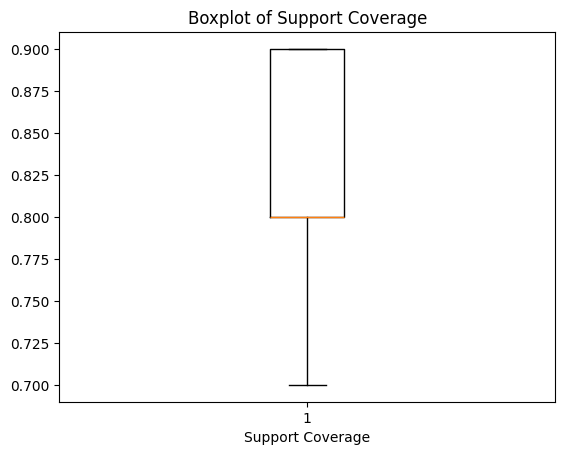

In [38]:
plt.figure()
plt.boxplot(cover_support, vert=True)
plt.xlabel("Support Coverage")
plt.title("Boxplot of Support Coverage")
plt.show()

In [36]:
print(cover_support)

[0.9 0.9 0.9 0.8 0.8 0.8 0.9 0.8 0.9 0.8 0.9 0.8 0.8 0.8 0.8 0.9 0.9 0.8
 0.8 0.9 0.8 0.8 0.8 0.8 0.8 0.9 0.9 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8
 0.9 0.8 0.8 0.9 0.9 0.8 0.8 0.8 0.8 0.8 0.9 0.8 0.8 0.8 0.8 0.9 0.9 0.9
 0.8 0.8 0.9 0.8 0.9 0.8 0.9 0.8 0.9 0.8 0.8 0.9 0.8 0.8 0.8 0.7 0.8 0.8
 0.8 0.9 0.9 0.8 0.8 0.8 0.8 0.9 0.9 0.9 0.9 0.8 0.7 0.8 0.9 0.9 0.8 0.9
 0.9 0.9 0.8 0.9 0.8 0.9 0.8 0.8 0.9 0.8]
